# Error Analysis

Import Libraries and Set Paths

In [5]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

# Paths
PRED_DIR = "../Data/polyvore_outfits/a_new_data/clip_results"
GT_PATH = "../Data/polyvore_outfits/a_new_data/split/test/test.csv"
SAVE_DIR = "error_analysis_results"
TABLES_DIR = os.path.join(SAVE_DIR, "tables")
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

# Load ground truth
gt = pd.read_csv(GT_PATH)
print("Ground truth shape:", gt.shape)
print(gt.head(5))

Ground truth shape: (3599, 6)
    image_id   category sub_category  color       material          pattern
0  192735532       tops      sweater  white  cotton-poplin     lace-trimmed
1  170155476       tops         tank  black      polyester           floral
2  201878750    bottoms        pants   ecru          linen  ticking stripes
3  155380799  outerwear  trench coat   gold       faux fur            plain
4  191570782    scarves        scarf   gold       cashmere      giant check


In [27]:
# Load all prediction CSVs without assumptions about column names
pred_files = [f for f in os.listdir(PRED_DIR) if f.endswith(".csv")]
if not pred_files:
    raise FileNotFoundError(f"No CSV files found in {PRED_DIR}")

preds = {}
for f in sorted(pred_files):
    name = f.replace(".csv", "")
    df = pd.read_csv(os.path.join(PRED_DIR, f))
    if "image_id" not in df.columns:
        raise KeyError(f"'image_id' column not found in {f}. Available columns: {list(df.columns)}")
    preds[name] = df
    print(f"{name}: shape={df.shape}, columns={list(df.columns)}")

model_names = list(preds.keys()) 

clip: shape=(3599, 6), columns=['image_id', 'category', 'sub_category', 'color', 'material', 'pattern']
fashion_clip: shape=(3599, 6), columns=['image_id', 'category', 'sub_category', 'color', 'material', 'pattern']
full: shape=(3599, 6), columns=['image_id', 'category', 'sub_category', 'color', 'material', 'pattern']
hybrid: shape=(3599, 6), columns=['image_id', 'category', 'sub_category', 'color', 'material', 'pattern']
linear_probe: shape=(3599, 6), columns=['image_id', 'category', 'sub_category', 'color', 'material', 'pattern']
prompt: shape=(3599, 6), columns=['image_id', 'category', 'sub_category', 'color', 'material', 'pattern']


build each attribute's table for analysis

In [6]:
# Load ground truth
gt = pd.read_csv(GT_PATH)

# Load all model prediction CSVs
pred_files = [f for f in os.listdir(PRED_DIR) if f.endswith(".csv")]
if not pred_files:
    raise FileNotFoundError(f"No CSV files found in {PRED_DIR}")

preds = {}
for f in sorted(pred_files):
    name = f.replace(".csv", "")
    df = pd.read_csv(os.path.join(PRED_DIR, f))
    if "image_id" not in df.columns:
        raise KeyError(f"'image_id' not found in {f}. Columns: {list(df.columns)}")
    preds[name] = df
    print(f"Loaded {name}: {df.shape}")

model_names = list(preds.keys())  # e.g. ['clip','fashion_clip','linear_probe','prompt','hybrid','full']

# Ensure table output folder exists
os.makedirs(TABLES_DIR, exist_ok=True)

# ---------------------------------------------------------------------
# Create five tables: category, sub_category, color, material, pattern
# ---------------------------------------------------------------------
FIELDS = ["category", "sub_category", "color", "material", "pattern"]
tables = {}

for field in FIELDS:
    # Start with ground truth image_id and its label
    df_field = gt[["image_id", field]].rename(columns={field: "ground_truth"})

    # For each model, align by image_id and add the prediction column
    for m in model_names:
        pred_df = preds[m][["image_id", field]]
        df_field = df_field.merge(pred_df, on="image_id", how="left", suffixes=("", f"_{m}"))
        df_field.rename(columns={field: m}, inplace=True)

    # Save and store
    out_path = os.path.join(TABLES_DIR, f"{field}_error_table.csv")
    df_field.to_csv(out_path, index=False)
    tables[field] = df_field

    print(f"\n=== {field.upper()} table preview ===")
    print(df_field.head())

print("\nAll tables saved in:", TABLES_DIR)

Loaded clip: (3599, 6)
Loaded fashion_clip: (3599, 6)
Loaded full: (3599, 6)
Loaded hybrid: (3599, 6)
Loaded linear_probe: (3599, 6)
Loaded prompt: (3599, 6)

=== CATEGORY table preview ===
    image_id ground_truth       clip fashion_clip      full     hybrid  \
0  192735532         tops       tops         tops      tops  outerwear   
1  170155476         tops       tops         tops  all-body       tops   
2  201878750      bottoms       tops      bottoms   scarves       tops   
3  155380799    outerwear  outerwear    outerwear   scarves  outerwear   
4  191570782      scarves    scarves      scarves   scarves    scarves   

  linear_probe     prompt  
0         tops       tops  
1         tops       tops  
2      bottoms       tops  
3    outerwear  outerwear  
4      scarves    scarves  

=== SUB_CATEGORY table preview ===
    image_id ground_truth          clip  fashion_clip          full  \
0  192735532      sweater        blouse        blouse        bowtie   
1  170155476       

check the unique values in category and subcategory

In [10]:
category_df = tables["category"]
subcategory_df = tables["sub_category"]
# Check unique values for ground_truth in category and sub_category tables

# Category
cat_unique_values = category_df["ground_truth"].dropna().unique()
cat_unique_count = len(cat_unique_values)

print(f"=== CATEGORY ground_truth unique values ===")
print(f"Count: {cat_unique_count}")
print(sorted(cat_unique_values))

# Sub-category
subcat_unique_values = subcategory_df["ground_truth"].dropna().unique()
subcat_unique_count = len(subcat_unique_values)

print(f"\n=== SUB_CATEGORY ground_truth unique values ===")
print(f"Count: {subcat_unique_count}")
print(sorted(subcat_unique_values))


=== CATEGORY ground_truth unique values ===
Count: 10
['accessories', 'all-body', 'bags', 'bottoms', 'hats', 'jewellery', 'outerwear', 'scarves', 'shoes', 'tops']

=== SUB_CATEGORY ground_truth unique values ===
Count: 73
['backpack', 'belt', 'blazer', 'blouse', 'bodie', 'boots', 'bowtie', 'bracelet', 'cardigan', 'closed shoes', 'clutch', 'dress', 'earrings', 'flat boots', 'flat sandals', 'flats', 'flip-flops', 'gloves', 'gown', 'headband', 'heeled boots', 'heels', 'hoodie', 'hosiery', 'jacket', 'jeans', 'jumpsuit', 'kimono', 'long skirt', 'male accessories', 'male baseball caps', 'male jeans', 'male knee-length shorts', 'male pants', 'male scarves', 'male shirt', 'male shoes', 'male sneakers', 'male t-shirt', 'necklace', 'one-piece swimsuit', 'over-the-knee boots', 'pants', 'platform shoes', 'pouch', 'pump', 'purse', 'pyjama pants', 'ring', 'romper', 'scarf', 'shorts', 'skirt', 'slippers', 'sneakers', 'socks', 'sports bra', 'sports long-sleeve shirt', 'straw hat', 'sunglasses', 'sweat

In [11]:
# Cell 1: Utilities and plotting helpers (single and multi-label)

import ast
import math
from collections import Counter, defaultdict
from itertools import product

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional libs
try:
    from matplotlib_venn import venn3
    HAVE_VENN = True
except Exception as e:
    HAVE_VENN = False
    print("[Info] matplotlib_venn not available. Venn diagrams will be skipped. Error:", str(e))

MAX_LABELS = 10

# Sanity paths from previous cells
print("SAVE_DIR:", SAVE_DIR)
print("TABLES_DIR:", TABLES_DIR)
print("Available tables:", list(tables.keys()))

# General figure saving helper
def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("[Saved]", path)

# Safe literal eval for list-like strings
def safe_to_list(x):
    if isinstance(x, list):
        return x
    if isinstance(x, (set, tuple)):
        return list(x)
    if pd.isna(x):
        return []
    s = str(x)
    s = s.strip()
    if s == "":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, (list, tuple, set)):
            return list(v)
        return [str(v)]
    except Exception:
        # Split on comma as the last resort
        # Remove surrounding quotes and stray brackets
        s2 = s.strip("[](){}")
        parts = [p.strip(" '\"") for p in s2.split(",") if p.strip(" '\"")]
        return parts

# Canonical normalization for labels (simple heuristic)
def canonicalize_label(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = s.strip().lower()
    s = s.replace("-", " ").replace("_", " ")
    s = re.sub(r"\s+", " ", s)
    # simple plural normalize
    if s.endswith("s") and len(s) > 3:
        s = s[:-1]
    # remove punctuation
    s = re.sub(r"[^\w\s]", "", s)
    return s

def canonicalize_list(lst):
    return [canonicalize_label(x) for x in safe_to_list(lst)]

# Compute per-class accuracy for single-label classification
def per_class_accuracy(gt_labels, pred_labels, class_order=None):
    gt_labels = [canonicalize_label(x) for x in gt_labels]
    pred_labels = [canonicalize_label(x) for x in pred_labels]
    if class_order is None:
        class_order = sorted(set(gt_labels))
    accs = {}
    for c in class_order:
        idx = [i for i, g in enumerate(gt_labels) if g == c]
        if not idx:
            accs[c] = np.nan
            continue
        correct = sum(1 for i in idx if pred_labels[i] == c)
        accs[c] = correct / len(idx)
    return accs

# Build confusion matrix for single-label tasks
def plot_confusion_matrix(gt_labels, pred_labels, labels, title, out_path, max_labels=MAX_LABELS):
    gt_c = [canonicalize_label(x) for x in gt_labels]
    pr_c = [canonicalize_label(x) for x in pred_labels]

    # If too many labels, keep top by frequency to maintain readability
    label_counts = Counter(gt_c)
    if len(labels) > max_labels:
        top = [l for l, _ in label_counts.most_common(max_labels)]
        mask = [g in top for g in gt_c]
        gt_c = [g for g, m in zip(gt_c, mask) if m]
        pr_c = [p for p, m in zip(pr_c, mask) if m]
        labels = top
        print(f"[Info] Confusion Matrix truncated to top {max_labels} labels by frequency.")
    cm = confusion_matrix(gt_c, pr_c, labels=labels)
    fig = plt.figure(figsize=(8, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
    plt.yticks(ticks=range(len(labels)), labels=labels)
    plt.colorbar()
    save_fig(out_path)
    plt.close(fig)

# Grouped bar for per-class accuracy across models
def plot_per_class_acc_bar(class_acc_dict_by_model, title, out_path, max_labels=MAX_LABELS):
    # Determine union of labels and then take top frequent if too many
    all_labels = sorted(set().union(*[set(d.keys()) for d in class_acc_dict_by_model.values()]))
    # keep ordering by average availability
    # If too many labels, slice
    if len(all_labels) > max_labels:
        # pick labels that have most non-nan across models
        label_scores = []
        for lab in all_labels:
            vals = []
            for m in class_acc_dict_by_model:
                v = class_acc_dict_by_model[m].get(lab, np.nan)
                if not (isinstance(v, float) and math.isnan(v)):
                    vals.append(v)
            label_scores.append((lab, len(vals)))
        label_scores.sort(key=lambda x: (-x[1], x[0]))
        all_labels = [lab for lab, _ in label_scores[:max_labels]]
        print(f"[Info] Per-class bar truncated to top {max_labels} labels by availability.")
    n_labels = len(all_labels)
    n_models = len(class_acc_dict_by_model)
    x = np.arange(n_labels)
    width = 0.8 / n_models

    fig = plt.figure(figsize=(max(10, n_labels * 0.35), 6))
    for i, m in enumerate(class_acc_dict_by_model.keys()):
        vals = [class_acc_dict_by_model[m].get(lab, np.nan) for lab in all_labels]
        plt.bar(x + i * width, vals, width=width, label=m)
    plt.title(title)
    plt.ylabel("Accuracy")
    plt.xticks(x + (n_models-1)*width/2, all_labels, rotation=90)
    plt.ylim(0, 1.0)
    plt.legend()
    save_fig(out_path)
    plt.close(fig)

# Venn diagram for error overlap of three models (single-label)
def plot_error_overlap_venn(gt_labels, pred_a, pred_b, pred_c, labels=("A","B","C"), title="", out_path=""):
    if not HAVE_VENN:
        print("[Skip] Venn plot skipped due to missing matplotlib_venn.")
        return
    gt_c = [canonicalize_label(x) for x in gt_labels]
    a_c = [canonicalize_label(x) for x in pred_a]
    b_c = [canonicalize_label(x) for x in pred_b]
    c_c = [canonicalize_label(x) for x in pred_c]
    wrong_a = set([i for i,(g,p) in enumerate(zip(gt_c,a_c)) if g != p])
    wrong_b = set([i for i,(g,p) in enumerate(zip(gt_c,b_c)) if g != p])
    wrong_c = set([i for i,(g,p) in enumerate(zip(gt_c,c_c)) if g != p])

    fig = plt.figure(figsize=(6,6))
    venn3(subsets=(wrong_a, wrong_b, wrong_c), set_labels=labels)
    plt.title(title)
    save_fig(out_path)
    plt.close(fig)

# Sankey diagram: GT -> Model1 -> Model2 (single-label)
def plot_sankey_gt_m1_m2(gt_labels, m1_labels, m2_labels, title, out_path, max_nodes=25):
    # build flow counts for pairs (GT->M1) and (M1->M2)
    gt_c = [canonicalize_label(x) for x in gt_labels]
    m1_c = [canonicalize_label(x) for x in m1_labels]
    m2_c = [canonicalize_label(x) for x in m2_labels]

    pairs_1 = Counter(zip(gt_c, m1_c))
    pairs_2 = Counter(zip(m1_c, m2_c))

    # Reduce to top nodes by frequency to avoid clutter
    gt_counts = Counter(gt_c)
    m1_counts = Counter(m1_c)
    m2_counts = Counter(m2_c)

    top_gt = set([l for l,_ in gt_counts.most_common(max_nodes)])
    top_m1 = set([l for l,_ in m1_counts.most_common(max_nodes)])
    top_m2 = set([l for l,_ in m2_counts.most_common(max_nodes)])

    # Build node lists
    nodes_gt = sorted(top_gt)
    nodes_m1 = sorted(top_m1)
    nodes_m2 = sorted(top_m2)

    # Map to indices
    idx_gt = {l:i for i,l in enumerate(nodes_gt)}
    idx_m1 = {l:i+len(nodes_gt) for i,l in enumerate(nodes_m1)}
    idx_m2 = {l:i+len(nodes_gt)+len(nodes_m1) for i,l in enumerate(nodes_m2)}

    # Build link lists
    src, dst, val = [], [], []
    for (g,m1), v in pairs_1.items():
        if g in idx_gt and m1 in idx_m1:
            src.append(idx_gt[g]); dst.append(idx_m1[m1]); val.append(v)
    for (m1,m2), v in pairs_2.items():
        if m1 in idx_m1 and m2 in idx_m2:
            src.append(idx_m1[m1]); dst.append(idx_m2[m2]); val.append(v)

    if not val:
        print("[Info] No flows to display for Sankey.")
        return

    # Plot with matplotlib's Sankey is limited; use simple network layout with weighted edges instead
    # We will emulate a left->middle->right layered graph using scatter + line widths.
    fig = plt.figure(figsize=(10, max(6, len(nodes_gt)*0.2)))
    # x positions
    x_gt, x_m1, x_m2 = 0.1, 0.5, 0.9
    # y positions spaced
    y_gt = np.linspace(0.9, 0.1, len(nodes_gt)) if nodes_gt else []
    y_m1 = np.linspace(0.9, 0.1, len(nodes_m1)) if nodes_m1 else []
    y_m2 = np.linspace(0.9, 0.1, len(nodes_m2)) if nodes_m2 else []

    # Draw links
    for s,d,v in zip(src,dst,val):
        # get x,y
        if s < len(nodes_gt):
            xs, ys = x_gt, y_gt[s]
        elif s < len(nodes_gt)+len(nodes_m1):
            i = s - len(nodes_gt)
            xs, ys = x_m1, y_m1[i]
        else:
            i = s - len(nodes_gt) - len(nodes_m1)
            xs, ys = x_m2, y_m2[i]
        if d < len(nodes_gt):
            xd, yd = x_gt, y_gt[d]
        elif d < len(nodes_gt)+len(nodes_m1):
            i = d - len(nodes_gt)
            xd, yd = x_m1, y_m1[i]
        else:
            i = d - len(nodes_gt) - len(nodes_m1)
            xd, yd = x_m2, y_m2[i]
        lw = 0.5 + 4.5 * (v / max(val))
        plt.plot([xs, xd], [ys, yd], linewidth=lw, alpha=0.6)

    # Draw nodes
    plt.scatter([x_gt]*len(nodes_gt), y_gt, s=60)
    plt.scatter([x_m1]*len(nodes_m1), y_m1, s=60)
    plt.scatter([x_m2]*len(nodes_m2), y_m2, s=60)

    # Labels
    for i,l in enumerate(nodes_gt):
        plt.text(x_gt-0.03, y_gt[i], l, va='center', ha='right')
    for i,l in enumerate(nodes_m1):
        plt.text(x_m1, y_m1[i], l, va='center', ha='center')
    for i,l in enumerate(nodes_m2):
        plt.text(x_m2+0.03, y_m2[i], l, va='center', ha='left')

    plt.axis('off')
    plt.title(title)
    save_fig(out_path)
    plt.close(fig)


SAVE_DIR: error_analysis_results
TABLES_DIR: error_analysis_results/tables
Available tables: ['category', 'sub_category', 'color', 'material', 'pattern']


In [40]:
# Cell 2: Single-label visualizations
# 1) Confusion matrices for all models (category, sub_category)
# 2) Per-class accuracy bar chart (grouped by model)
# 3) Error overlap Venn diagram for CLIP, fashion_clip, linear_probe
# 4) Error transition Sankey diagram GT->CLIP->linear_probe

SIN_LABEL = os.path.join(SAVE_DIR, "1_single_label_visualizations")

single_fields = ["category", "sub_category"]
single_model_names = model_names  # all models present in your predictions

for field in single_fields:
    df = tables[field]
    gt_labels = df["ground_truth"].tolist()
    # Compute label order by GT frequency
    label_order = sorted(set(canonicalize_label(x) for x in gt_labels))
    # 1) Confusion matrices for each model
    for m in single_model_names:
        preds_m = df[m].tolist()
        out_path = os.path.join(SIN_LABEL, f"{field}_confusion_{m}.png")
        plot_confusion_matrix(gt_labels, preds_m, labels=label_order,
                              title=f"{field} - Confusion Matrix ({m})",
                              out_path=out_path, max_labels=10)
    print(f"[Done] Confusion matrices for {field}")

    # 2) Per-class accuracy bar chart across models
    class_acc_by_model = {}
    for m in single_model_names:
        accs = per_class_accuracy(gt_labels, df[m].tolist(), class_order=label_order)
        class_acc_by_model[m] = accs
    out_bar = os.path.join(SIN_LABEL, f"{field}_per_class_accuracy.png")
    plot_per_class_acc_bar(class_acc_by_model,
                           title=f"{field} - Per-Class Accuracy (All Models)",
                           out_path=out_bar, max_labels=10)
    print(f"[Done] Per-class accuracy bar for {field}")

    # 3) Error overlap Venn: CLIP, fashion_clip, linear_probe
    lower_models = [m.lower() for m in single_model_names]
    try_models = {}
    for key in ["clip", "fashion_clip", "linear_probe"]:
        if key in lower_models:
            orig = single_model_names[lower_models.index(key)]
            try_models[key] = df[orig].tolist()
        else:
            print(f"[Warn] '{key}' predictions not found; skipping Venn component.")
    if len(try_models) == 3:
        out_venn = os.path.join(SIN_LABEL, f"{field}_error_overlap_venn.png")
        plot_error_overlap_venn(
            gt_labels,
            try_models["clip"],
            try_models["fashion_clip"],
            try_models["linear_probe"],
            labels=("CLIP","FashionCLIP","LinearProbe"),
            title=f"{field} - Error Overlap (Venn)",
            out_path=out_venn
        )
        print(f"[Done] Venn for {field}")
    else:
        print(f"[Skip] Venn for {field} due to missing models or venn package.")

    # 4) Sankey GT->CLIP->linear_probe
    if all(k in try_models for k in ["clip","linear_probe"]):
        out_sankey = os.path.join(SIN_LABEL, f"{field}_sankey_gt_clip_linear.png")
        plot_sankey_gt_m1_m2(
            gt_labels,
            try_models["clip"],
            try_models["linear_probe"],
            title=f"{field} - Flow: GT → CLIP → LinearProbe",
            out_path=out_sankey,
            max_nodes=25
        )
        print(f"[Done] Sankey for {field}")
    else:
        print(f"[Skip] Sankey for {field} due to missing models.")

print("[Summary] Single-label visuals focus on showing where models confuse classes, which classes are weak, where errors overlap across baselines, and how errors transition from GT to CLIP to LinearProbe. Purpose: reveal systematic confusions and improvements potential.")


[Saved] error_analysis_results/1_single_label_visualizations/category_confusion_clip.png
[Saved] error_analysis_results/1_single_label_visualizations/category_confusion_fashion_clip.png
[Saved] error_analysis_results/1_single_label_visualizations/category_confusion_full.png
[Saved] error_analysis_results/1_single_label_visualizations/category_confusion_hybrid.png
[Saved] error_analysis_results/1_single_label_visualizations/category_confusion_linear_probe.png
[Saved] error_analysis_results/1_single_label_visualizations/category_confusion_prompt.png
[Done] Confusion matrices for category
[Saved] error_analysis_results/1_single_label_visualizations/category_per_class_accuracy.png
[Done] Per-class accuracy bar for category
[Saved] error_analysis_results/1_single_label_visualizations/category_error_overlap_venn.png
[Done] Venn for category
[Saved] error_analysis_results/1_single_label_visualizations/category_sankey_gt_clip_linear.png
[Done] Sankey for category
[Info] Confusion Matrix trunca

In [15]:
# Cell 3: Multi-label semantic matching via CLIP (text encoder)
# This cell builds semantic matches table per task (color/material/pattern) and per model.
# If CLIP is unavailable, a fallback approximate matcher is used.

SEMANTIC_DIR = os.path.join(SAVE_DIR, "semantic_matches")
# Parameters
MULTI_FIELDS = ["color", "material", "pattern"]
SEM_THRESHOLD = 0.80  # cosine similarity threshold
TOP_K = 50            # visualization top-k labels default

# Try to load CLIP for text embeddings
HAVE_CLIP = False
clip_model = None
clip_preprocess = None
clip_device = "cpu"

try:
    import torch
    import clip  
    if torch.cuda.is_available():
        clip_device = "cuda"
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=clip_device)
    HAVE_CLIP = True
    print("[Info] CLIP loaded on", clip_device)
except Exception as e:
    print("[Info] CLIP not available, fallback matcher will be used. Error:", str(e))

def embed_texts_with_clip(texts):
    # Returns L2-normalized embeddings (numpy array)
    import torch
    with torch.no_grad():
        tokens = clip.tokenize(texts, truncate=True).to(clip_device)
        feats = clip_model.encode_text(tokens).float()
        feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy()

def pairwise_cosine(a, b):
    # a: NxD, b: MxD
    # returns NxM cosine sims
    return (a @ b.T)

# Fallback matcher: simple canonical exact/substring match score
def fallback_similarity(a_list, b_list):
    # Return similarity matrix using token overlap Jaccard as proxy
    def tokset(s):
        s = canonicalize_label(s)
        return set([t for t in s.split() if t])
    A = [tokset(x) for x in a_list]
    B = [tokset(x) for x in b_list]
    sims = np.zeros((len(A), len(B)), dtype=float)
    for i,a in enumerate(A):
        for j,b in enumerate(B):
            if len(a|b) == 0:
                sims[i,j] = 0.0
            else:
                sims[i,j] = len(a&b) / len(a|b)
    return sims

def build_semantic_map_for_field(field_df, field_name):
    # Build semantic matches for each model for multi-label task
    # Returns long table of matches per image_id, per model, per predicted label
    records = []
    gt_lists = [canonicalize_list(x) for x in field_df["ground_truth"]]
    image_ids = field_df["image_id"].tolist()

    # collect universe of GT labels for embedding once
    gt_vocab = sorted(set(l for lst in gt_lists for l in lst if l))

    # prepare GT embeddings if CLIP available
    if HAVE_CLIP:
        gt_emb = embed_texts_with_clip(gt_vocab) if gt_vocab else np.zeros((0,512))
    else:
        gt_emb = None

    for m in model_names:
        pred_lists = [canonicalize_list(x) for x in field_df[m]]
        pred_vocab = sorted(set(l for lst in pred_lists for l in lst if l))
        if HAVE_CLIP:
            pred_emb = embed_texts_with_clip(pred_vocab) if pred_vocab else np.zeros((0,512))
            sims_vocab = pairwise_cosine(gt_emb, pred_emb) if (len(gt_vocab)>0 and len(pred_vocab)>0) else np.zeros((0,0))
        else:
            sims_vocab = fallback_similarity(gt_vocab, pred_vocab)

        # Build a fast vocab index
        idx_gt = {l:i for i,l in enumerate(gt_vocab)}
        idx_pr = {l:i for i,l in enumerate(pred_vocab)}

        # For each image, compute matches and error types
        for img, gt_labs, pr_labs in zip(image_ids, gt_lists, pred_lists):
            gt_idx = [idx_gt[l] for l in gt_labs if l in idx_gt]
            pr_idx = [idx_pr[l] for l in pr_labs if l in idx_pr]

            # Build per-pair best matches
            matched_gt = set()
            matched_pr = set()
            pairs = []

            for gi in gt_idx:
                # find best pred for this gt
                best_p = None
                best_s = -1.0
                for pj in pr_idx:
                    s = sims_vocab[gi, pj] if sims_vocab.size else 0.0
                    if s > best_s:
                        best_s = s
                        best_p = pj
                if best_p is not None and best_s >= SEM_THRESHOLD:
                    matched_gt.add(gi)
                    matched_pr.add(best_p)
                    pairs.append(("TP", gt_vocab[gi], pred_vocab[best_p], float(best_s)))
                else:
                    pairs.append(("FN", gt_vocab[gi], "", float(best_s if best_s>=0 else 0.0)))

            # Remaining unmatched preds are FP
            for pj in pr_idx:
                if pj not in matched_pr:
                    # find closest gt for reference score
                    best_s = 0.0
                    if sims_vocab.size and gt_idx:
                        best_s = float(np.max(sims_vocab[[*gt_idx], pj]))
                    pairs.append(("FP", "", pred_vocab[pj], best_s))

            # Write records
            for t, g, p, s in pairs:
                records.append({
                    "image_id": img,
                    "model": m,
                    "field": field_name,
                    "type": t,
                    "gt_label": g,
                    "pred_label": p,
                    "similarity": s
                })

    out_df = pd.DataFrame(records)
    out_csv = os.path.join(SEMANTIC_DIR, f"{field_name}_semantic_matches.csv")
    out_df.to_csv(out_csv, index=False)
    print(f"[Saved] Semantic matches table for {field_name} ->", out_csv)
    return out_df

semantic_tables = {}
for f in MULTI_FIELDS:
    semantic_tables[f] = build_semantic_map_for_field(tables[f], f)

print("[Summary] This step computes semantic TP/FP/FN using CLIP (or a fallback). Purpose: respect synonymy and near-duplicates so that error analysis reflects semantic correctness, not string exactness.")

[Info] CLIP loaded on cpu
[Saved] Semantic matches table for color -> error_analysis_results/semantic_matches/color_semantic_matches.csv
[Saved] Semantic matches table for material -> error_analysis_results/semantic_matches/material_semantic_matches.csv
[Saved] Semantic matches table for pattern -> error_analysis_results/semantic_matches/pattern_semantic_matches.csv
[Summary] This step computes semantic TP/FP/FN using CLIP (or a fallback). Purpose: respect synonymy and near-duplicates so that error analysis reflects semantic correctness, not string exactness.


In [34]:
# Cell 4: Multi-label quantitative visualizations (Bar / Confusion / Heatmap / Venn)
# For each multi-label field:
# - Per-label Precision/Recall/F1 (Top-K by frequency)
# - Semantic confusion heatmap (Top-K GT->Pred pairs)
# - Label co-occurrence heatmap (GT vs model)
# - Error overlap Venn for CLIP, FashionCLIP, LinearProbe (on sample space)
MULTI_VISUAL = os.path.join(SAVE_DIR, "multi_label_visualizations")

def compute_per_label_prf(sem_df, model_name):
    # Compute precision, recall, F1 per GT label using semantic matches
    # We consider:
    #   TP: type == "TP" with non-empty gt_label and pred_label
    #   FN: type == "FN" with gt_label non-empty
    #   FP: type == "FP" with pred_label non-empty
    stats = {}
    dfm = sem_df[sem_df["model"] == model_name]
    # labels are union of gt_label and pred_label
    labels = sorted(set(x for x in dfm["gt_label"].unique() if x) | set(x for x in dfm["pred_label"].unique() if x))
    for lab in labels:
        tp = len(dfm[(dfm["type"]=="TP") & (dfm["gt_label"]==lab)])
        fp = len(dfm[(dfm["type"]=="FP") & (dfm["pred_label"]==lab)])
        fn = len(dfm[(dfm["type"]=="FN") & (dfm["gt_label"]==lab)])
        prec = tp / (tp + fp) if (tp+fp)>0 else 0.0
        rec  = tp / (tp + fn) if (tp+fn)>0 else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        stats[lab] = (prec, rec, f1, tp+fp+fn)
    return stats

def plot_topk_prf_bars(stats_by_model, title, out_path, top_k=50, metric="f1"):
    # Select labels by total support across models
    support = Counter()
    for m, d in stats_by_model.items():
        for lab, (_,_,_,supp) in d.items():
            support[lab] += supp
    labels = [l for l,_ in support.most_common(top_k)]
    x = np.arange(len(labels))
    width = 0.8 / len(stats_by_model)

    fig = plt.figure(figsize=(max(10, len(labels)*0.35), 6))
    for i,(m,d) in enumerate(stats_by_model.items()):
        if metric == "precision":
            vals = [d.get(l, (0,0,0,0))[0] for l in labels]
        elif metric == "recall":
            vals = [d.get(l, (0,0,0,0))[1] for l in labels]
        else:
            vals = [d.get(l, (0,0,0,0))[2] for l in labels]
        plt.bar(x + i*width, vals, width=width, label=m)
    plt.title(title + f" (Top-{top_k} by support)")
    plt.ylabel(metric.capitalize())
    plt.xticks(x + (len(stats_by_model)-1)*width/2, labels, rotation=90)
    plt.ylim(0, 1.0)
    plt.legend()
    save_fig(out_path)
    plt.close(fig)

def top_confusion_pairs(sem_df, model_name, top_k=50):
    # Aggregate counts of GT->Pred pairs for TP and near-miss FP
    dfm = sem_df[sem_df["model"] == model_name]
    # take only pairs with non-empty both sides
    pairs = dfm[(dfm["gt_label"]!="") & (dfm["pred_label"]!="")]
    agg = pairs.groupby(["gt_label","pred_label"]).size().reset_index(name="count")
    agg = agg.sort_values("count", ascending=False).head(top_k)
    return agg

def plot_confusion_pairs_heatmap(agg_pairs_df, title, out_path):
    if agg_pairs_df.empty:
        print("[Info] No confusion pairs to draw.")
        return
    rows = agg_pairs_df["gt_label"].unique().tolist()
    cols = agg_pairs_df["pred_label"].unique().tolist()
    mat = np.zeros((len(rows), len(cols)), dtype=int)
    for _,r in agg_pairs_df.iterrows():
        i = rows.index(r["gt_label"])
        j = cols.index(r["pred_label"])
        mat[i,j] = r["count"]
    fig = plt.figure(figsize=(max(8, len(cols)*0.3), max(6, len(rows)*0.3)))
    plt.imshow(mat, interpolation='nearest')
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("Ground truth label")
    plt.xticks(range(len(cols)), cols, rotation=90)
    plt.yticks(range(len(rows)), rows)
    plt.colorbar()
    save_fig(out_path)
    plt.close(fig)

def build_cooccurrence_matrix(label_lists, top_k=50):
    # label_lists: list of list[str]
    flat = [l for lst in label_lists for l in lst]
    freq = Counter(flat)
    top = [l for l,_ in freq.most_common(top_k)]
    idx = {l:i for i,l in enumerate(top)}
    mat = np.zeros((len(top), len(top)), dtype=int)
    for lst in label_lists:
        s = [l for l in lst if l in idx]
        for i in range(len(s)):
            for j in range(i, len(s)):
                ii, jj = idx[s[i]], idx[s[j]]
                mat[ii,jj] += 1
                if ii != jj:
                    mat[jj,ii] += 1
    return top, mat

def plot_heatmap_square(labels, mat, title, out_path):
    fig = plt.figure(figsize=(max(8, len(labels)*0.3), max(6, len(labels)*0.3)))
    plt.imshow(mat, interpolation='nearest')
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    save_fig(out_path)
    plt.close(fig)

for field in MULTI_FIELDS:
    sem = semantic_tables[field]
    # Compute PRF for several models
    stats_all = {}
    for m in model_names:
        stats_all[m] = compute_per_label_prf(sem, m)

    # Plot F1 bars (Top-K by support)
    out_bar = os.path.join(MULTI_VISUAL, f"{field}_top{TOP_K}_per_label_f1.png")
    plot_topk_prf_bars(stats_all, title=f"{field} - Per-Label F1 by Model", out_path=out_bar, top_k=TOP_K, metric="f1")
    print(f"[Done] {field} F1 bars (Top-{TOP_K})")

    # Confusion pairs heatmap for a few representative models (CLIP, Full if available)
    for cand in ["clip","full","fashion_clip"]:
        if cand in [m.lower() for m in model_names]:
            orig = model_names[[m.lower() for m in model_names].index(cand)]
            agg_pairs = top_confusion_pairs(sem, orig, top_k=TOP_K)
            out_heat = os.path.join(MULTI_VISUAL, f"{field}_confusion_pairs_{cand}_top{TOP_K}.png")
            plot_confusion_pairs_heatmap(agg_pairs, title=f"{field} - Top Confusion Pairs ({orig})", out_path=out_heat)
            print(f"[Done] {field} confusion pairs heatmap for {orig}")

    # Co-occurrence heatmap: GT vs a model (e.g., CLIP)
    df_field = tables[field]
    gt_lists = [canonicalize_list(x) for x in df_field["ground_truth"]]
    top_gt, mat_gt = build_cooccurrence_matrix(gt_lists, top_k=TOP_K)
    out_co_gt = os.path.join(MULTI_VISUAL, f"{field}_gt_cooccurrence_top{TOP_K}.png")
    plot_heatmap_square(top_gt, mat_gt, title=f"{field} - Ground Truth Co-occurrence (Top-{TOP_K})", out_path=out_co_gt)
    print(f"[Done] {field} GT co-occurrence")

    lower_models = [m.lower() for m in model_names]
    if "clip" in lower_models:
        orig = model_names[lower_models.index("clip")]
        pred_lists = [canonicalize_list(x) for x in df_field[orig]]
        top_pr, mat_pr = build_cooccurrence_matrix(pred_lists, top_k=TOP_K)
        out_co_pr = os.path.join(MULTI_VISUAL, f"{field}_clip_cooccurrence_top{TOP_K}.png")
        plot_heatmap_square(top_pr, mat_pr, title=f"{field} - CLIP Co-occurrence (Top-{TOP_K})", out_path=out_co_pr)
        print(f"[Done] {field} CLIP co-occurrence")

    # Venn on sample-level errors among three models
    if HAVE_VENN and all(k in lower_models for k in ["clip","fashion_clip","linear_probe"]):
        df = tables[field]
        gt_sets = [set(canonicalize_list(x)) for x in df["ground_truth"]]
        def wrong_idx_of(model_col):
            pred_sets = [set(canonicalize_list(x)) for x in df[model_col]]
            wrong = set()
            for i,(g,p) in enumerate(zip(gt_sets, pred_sets)):
                # An item is considered wrong if semantic matches found no TP at all for this image
                # We use semantic table for a better notion of wrongness:
                # If there is at least one TP record for this image and model -> not fully wrong.
                sem_m = sem[(sem["model"]==model_col) & (sem["image_id"]==df.loc[i,"image_id"])]
                if not (sem_m["type"]=="TP").any():
                    wrong.add(i)
            return wrong

        names = {
            "clip": model_names[lower_models.index("clip")],
            "fashion_clip": model_names[lower_models.index("fashion_clip")],
            "linear_probe": model_names[lower_models.index("linear_probe")]
        }
        wrong_a = wrong_idx_of(names["clip"])
        wrong_b = wrong_idx_of(names["fashion_clip"])
        wrong_c = wrong_idx_of(names["linear_probe"])

        fig = plt.figure(figsize=(6,6))
        venn3([wrong_a, wrong_b, wrong_c], set_labels=("CLIP","FashionCLIP","LinearProbe"))
        out_venn = os.path.join(MULTI_VISUAL, f"{field}_semantic_error_overlap_venn.png")
        save_fig(out_venn)
        plt.close(fig)
        print(f"[Done] {field} semantic error overlap Venn")
    else:
        print(f"[Skip] {field} Venn due to missing package/models.")

print("[Summary] Multi-label quantitative visuals show per-label performance (Top-K), most frequent semantic confusions, co-occurrence structures, and cross-model error overlaps. Purpose: identify dominant failure modes and label relations driving errors.")

[Saved] error_analysis_results/multi_label_visualizations/color_top50_per_label_f1.png
[Done] color F1 bars (Top-50)
[Saved] error_analysis_results/multi_label_visualizations/color_confusion_pairs_clip_top50.png
[Done] color confusion pairs heatmap for clip
[Saved] error_analysis_results/multi_label_visualizations/color_confusion_pairs_full_top50.png
[Done] color confusion pairs heatmap for full
[Saved] error_analysis_results/multi_label_visualizations/color_confusion_pairs_fashion_clip_top50.png
[Done] color confusion pairs heatmap for fashion_clip
[Saved] error_analysis_results/multi_label_visualizations/color_gt_cooccurrence_top50.png
[Done] color GT co-occurrence
[Saved] error_analysis_results/multi_label_visualizations/color_clip_cooccurrence_top50.png
[Done] color CLIP co-occurrence
[Saved] error_analysis_results/multi_label_visualizations/color_semantic_error_overlap_venn.png
[Done] color semantic error overlap Venn
[Saved] error_analysis_results/multi_label_visualizations/mater

/var/folders/cs/x9dhh7d11xs530bnby8f9kfm0000gn/T/ipykernel_56825/3022106433.py:30: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[Saved] error_analysis_results/multi_label_visualizations/pattern_top50_per_label_f1.png
[Done] pattern F1 bars (Top-50)
[Saved] error_analysis_results/multi_label_visualizations/pattern_confusion_pairs_clip_top50.png
[Done] pattern confusion pairs heatmap for clip
[Saved] error_analysis_results/multi_label_visualizations/pattern_confusion_pairs_full_top50.png
[Done] pattern confusion pairs heatmap for full
[Saved] error_analysis_results/multi_label_visualizations/pattern_confusion_pairs_fashion_clip_top50.png
[Done] pattern confusion pairs heatmap for fashion_clip
[Saved] error_analysis_results/multi_label_visualizations/pattern_gt_cooccurrence_top50.png
[Done] pattern GT co-occurrence
[Saved] error_analysis_results/multi_label_visualizations/pattern_clip_cooccurrence_top50.png
[Done] pattern CLIP co-occurrence
[Saved] error_analysis_results/multi_label_visualizations/pattern_semantic_error_overlap_venn.png
[Done] pattern semantic error overlap Venn
[Summary] Multi-label quantitative 

In [35]:
# Cell 5: Semantic space visualization (t-SNE) and Sankey for multi-label
# - t-SNE on label embeddings (GT and selected model), annotate top labels only
# - Sankey-like flow GT->CLIP->Full (Top flows), per field
SPACE_DIR = os.path.join(SAVE_DIR, "semantic_space_visualizations")

def tsne_label_space(field, model_for_pred="clip", top_k=100):
    # Build embeddings for GT labels and model predicted labels
    df = tables[field]
    lower_models = [m.lower() for m in model_names]
    if model_for_pred not in lower_models:
        print(f"[Skip] t-SNE for {field}: model {model_for_pred} not found.")
        return
    model_col = model_names[lower_models.index(model_for_pred)]

    gt_lists = [canonicalize_list(x) for x in df["ground_truth"]]
    pr_lists = [canonicalize_list(x) for x in df[model_col]]

    gt_freq = Counter([l for lst in gt_lists for l in lst])
    pr_freq = Counter([l for lst in pr_lists for l in lst])

    gt_top = [l for l,_ in gt_freq.most_common(top_k)]
    pr_top = [l for l,_ in pr_freq.most_common(top_k)]

    labs = sorted(set(gt_top) | set(pr_top))
    if not labs:
        print(f"[Info] No labels for t-SNE in {field}.")
        return

    if not HAVE_CLIP:
        print("[Info] CLIP not available; t-SNE will use a trivial bag-of-chars embedding as fallback.")
        # trivial embedding: character counts vector
        chars = sorted(set("".join(labs)))
        X = np.zeros((len(labs), len(chars)), dtype=float)
        for i,l in enumerate(labs):
            for ch in l:
                if ch in chars:
                    X[i, chars.index(ch)] += 1.0
        X = normalize(X)
    else:
        X = embed_texts_with_clip(labs)

    # t-SNE
    emb2 = TSNE(n_components=2, perplexity=min(30, max(5, len(labs)//3)), init="random", learning_rate="auto", random_state=42).fit_transform(X)

    fig = plt.figure(figsize=(8, 6))
    plt.scatter(emb2[:,0], emb2[:,1], s=15, alpha=0.7)
    # annotate only a subset for readability
    annotate_n = min(40, len(labs))
    # select top by combined frequency
    combo_freq = Counter()
    for l in labs:
        combo_freq[l] = gt_freq.get(l,0) + pr_freq.get(l,0)
    ann_labels = [l for l,_ in combo_freq.most_common(annotate_n)]
    for l in ann_labels:
        i = labs.index(l)
        plt.text(emb2[i,0], emb2[i,1], l, fontsize=8)
    plt.title(f"{field} - Label Semantic Space (t-SNE) using {model_for_pred.upper()} top labels")
    out_path = os.path.join(SPACE_DIR, f"{field}_tsne_{model_for_pred}_top{top_k}.png")
    save_fig(out_path)
    plt.close(fig)
    print(f"[Done] t-SNE for {field} ({model_for_pred})")

def sankey_multilabel_gt_clip_full(field, top_pairs=60):
    # Build flows from GT label -> CLIP label -> FULL label using semantic matches table
    sem = semantic_tables[field]
    lower_models = [m.lower() for m in model_names]
    if "clip" not in lower_models or "full" not in lower_models:
        print(f"[Skip] Sankey for {field}: need CLIP and FULL.")
        return
    clip_m = model_names[lower_models.index("clip")]
    full_m = model_names[lower_models.index("full")]

    # Use pairs from semantic table where both sides present
    pairs_gt_clip = sem[(sem["model"]==clip_m) & (sem["gt_label"]!="") & (sem["pred_label"]!="")]
    pairs_clip_full = sem[(sem["model"]==full_m) & (sem["gt_label"]!="") & (sem["pred_label"]!="")]

    # For GT->CLIP, we use (gt_label -> clip_pred)
    agg1 = pairs_gt_clip.groupby(["gt_label","pred_label"]).size().reset_index(name="count")
    agg1 = agg1.sort_values("count", ascending=False).head(top_pairs)

    # For CLIP->FULL, we need bridge via image_id; approximate by label-to-label flow counts:
    # We simulate M1->M2 by linking predicted labels from CLIP to predicted labels from FULL on same images.
    # Build per-image predicted sets
    df = tables[field]
    clip_preds = {row.image_id: set(canonicalize_list(row[clip_m])) for _,row in df.iterrows()}
    full_preds = {row.image_id: set(canonicalize_list(row[full_m])) for _,row in df.iterrows()}
    # Build flow counts between labels observed together
    bridge = Counter()
    for img in df["image_id"]:
        for a in clip_preds.get(img, []):
            for b in full_preds.get(img, []):
                bridge[(a,b)] += 1
    agg2 = pd.DataFrame([(a,b,c) for (a,b),c in bridge.items()], columns=["clip_label","full_label","count"])
    agg2 = agg2.sort_values("count", ascending=False).head(top_pairs)

    # Build layered network plot like in single-label
    nodes_gt = sorted(set(agg1["gt_label"]))
    nodes_c  = sorted(set(agg1["pred_label"]) | set(agg2["clip_label"]))
    nodes_f  = sorted(set(agg2["full_label"]))

    idx_gt = {l:i for i,l in enumerate(nodes_gt)}
    idx_c  = {l:i+len(nodes_gt) for i,l in enumerate(nodes_c)}
    idx_f  = {l:i+len(nodes_gt)+len(nodes_c) for i,l in enumerate(nodes_f)}

    src, dst, val = [], [], []
    for _,r in agg1.iterrows():
        g, c, v = r["gt_label"], r["pred_label"], int(r["count"])
        if g in idx_gt and c in idx_c:
            src.append(idx_gt[g]); dst.append(idx_c[c]); val.append(v)
    for _,r in agg2.iterrows():
        c, f, v = r["clip_label"], r["full_label"], int(r["count"])
        if c in idx_c and f in idx_f:
            src.append(idx_c[c]); dst.append(idx_f[f]); val.append(v)

    if not val:
        print(f"[Info] No flows to draw for {field}.")
        return

    fig = plt.figure(figsize=(10, 8))
    x_gt, x_c, x_f = 0.1, 0.5, 0.9
    y_gt = np.linspace(0.9, 0.1, len(nodes_gt)) if nodes_gt else []
    y_c  = np.linspace(0.9, 0.1, len(nodes_c)) if nodes_c else []
    y_f  = np.linspace(0.9, 0.1, len(nodes_f)) if nodes_f else []

    for s,d,v in zip(src,dst,val):
        if s < len(nodes_gt):
            xs, ys = x_gt, y_gt[s]
        elif s < len(nodes_gt)+len(nodes_c):
            i = s - len(nodes_gt)
            xs, ys = x_c, y_c[i]
        else:
            i = s - len(nodes_gt) - len(nodes_c)
            xs, ys = x_f, y_f[i]
        if d < len(nodes_gt):
            xd, yd = x_gt, y_gt[d]
        elif d < len(nodes_gt)+len(nodes_c):
            i = d - len(nodes_gt)
            xd, yd = x_c, y_c[i]
        else:
            i = d - len(nodes_gt) - len(nodes_c)
            xd, yd = x_f, y_f[i]
        lw = 0.5 + 4.5 * (v / max(val))
        plt.plot([xs, xd], [ys, yd], linewidth=lw, alpha=0.6)

    plt.scatter([x_gt]*len(nodes_gt), y_gt, s=60)
    plt.scatter([x_c]*len(nodes_c), y_c, s=60)
    plt.scatter([x_f]*len(nodes_f), y_f, s=60)

    for i,l in enumerate(nodes_gt):
        plt.text(x_gt-0.03, y_gt[i], l, va='center', ha='right')
    for i,l in enumerate(nodes_c):
        plt.text(x_c, y_c[i], l, va='center', ha='center')
    for i,l in enumerate(nodes_f):
        plt.text(x_f+0.03, y_f[i], l, va='center', ha='left')

    plt.axis('off')
    plt.title(f"{field} - Flow: GT → CLIP → FULL (Top flows)")
    out_path = os.path.join(SPACE_DIR, f"{field}_sankey_gt_clip_full.png")
    save_fig(out_path)
    plt.close(fig)
    print(f"[Done] Sankey for {field}")

# Run t-SNE and Sankey per multi-label field
for f in MULTI_FIELDS:
    tsne_label_space(f, model_for_pred="clip", top_k=100)
    sankey_multilabel_gt_clip_full(f, top_pairs=60)

print("[Summary] Semantic space (t-SNE) reveals where labels cluster and where errors concentrate; Sankey shows how predictions flow from GT through CLIP to FULL. Purpose: expose structure of mistakes and how fine-tuning shifts predictions.")


[Saved] error_analysis_results/semantic_space_visualizations/color_tsne_clip_top100.png
[Done] t-SNE for color (clip)
[Saved] error_analysis_results/semantic_space_visualizations/color_sankey_gt_clip_full.png
[Done] Sankey for color
[Saved] error_analysis_results/semantic_space_visualizations/material_tsne_clip_top100.png
[Done] t-SNE for material (clip)
[Saved] error_analysis_results/semantic_space_visualizations/material_sankey_gt_clip_full.png
[Done] Sankey for material
[Saved] error_analysis_results/semantic_space_visualizations/pattern_tsne_clip_top100.png
[Done] t-SNE for pattern (clip)
[Saved] error_analysis_results/semantic_space_visualizations/pattern_sankey_gt_clip_full.png
[Done] Sankey for pattern
[Summary] Semantic space (t-SNE) reveals where labels cluster and where errors concentrate; Sankey shows how predictions flow from GT through CLIP to FULL. Purpose: expose structure of mistakes and how fine-tuning shifts predictions.


In [16]:
# Cell 6: Additional analytics I recommend (coverage curves, head/middle/tail error composition, top confusion tables)
# These are scalable summaries for very large class spaces.
ADD_ANALYTICS_DIR = os.path.join(SAVE_DIR, "additional_analytics")
MULTI_FIELDS = ["color", "material", "pattern"]

def cumulative_coverage_curve(label_lists, title, out_path):
    freq = Counter([l for lst in label_lists for l in lst])
    counts = [c for _,c in freq.most_common()]
    total = sum(counts) if counts else 1
    cum = np.cumsum(counts) / total
    fig = plt.figure(figsize=(8,4))
    plt.plot(np.arange(1, len(cum)+1), cum)
    plt.xlabel("Top-N labels by frequency")
    plt.ylabel("Cumulative coverage")
    plt.title(title)
    save_fig(out_path)
    plt.close(fig)

def head_middle_tail_bins(freq, head=50, middle=200):
    # Return a dict {label: bin_id} where bin_id in {"head","middle","tail"}
    order = [l for l,_ in freq.most_common()]
    mapping = {}
    for i,l in enumerate(order):
        if i < head:
            mapping[l] = "head"
        elif i < head + middle:
            mapping[l] = "middle"
        else:
            mapping[l] = "tail"
    return mapping

def error_composition_by_bins(sem_df, model_name, freq_map):
    # Compute TP/FP/FN ratios by bin
    res = {"head":[0,0,0], "middle":[0,0,0], "tail":[0,0,0]}
    dfm = sem_df[sem_df["model"]==model_name]
    for _,r in dfm.iterrows():
        lab = r["gt_label"] if r["gt_label"] else r["pred_label"]
        if not lab:
            continue
        bin_id = freq_map.get(lab, "tail")
        if r["type"]=="TP":
            res[bin_id][0]+=1
        elif r["type"]=="FP":
            res[bin_id][1]+=1
        elif r["type"]=="FN":
            res[bin_id][2]+=1
    return res

def plot_error_composition_bins(comp_by_model, title, out_path):
    bins = ["head","middle","tail"]
    fig = plt.figure(figsize=(8,5))
    x = np.arange(len(bins))
    width = 0.8 / len(comp_by_model)
    for i,(m,vals) in enumerate(comp_by_model.items()):
        totals = [sum(vals[b]) for b in bins]
        ratios = []
        for b in bins:
            tp,fp,fn = vals[b]
            tot = tp+fp+fn if (tp+fp+fn)>0 else 1
            ratios.append((tp+fp+fn)/tot)  # always 1.0 but we need stacked? keep simple:
        # Instead of stacked bar, show FP/FN rates separately via lines
    # Simple stacked bar per model per bin for TP/FP/FN
    width = 0.8 / len(comp_by_model)
    for i,(m,vals) in enumerate(comp_by_model.items()):
        tp = [vals[b][0] for b in bins]
        fp = [vals[b][1] for b in bins]
        fn = [vals[b][2] for b in bins]
        base = np.zeros(len(bins))
        plt.bar(x + i*width, tp, width=width, label=f"{m} TP")
        base += tp
        plt.bar(x + i*width, fp, bottom=base, width=width, label=f"{m} FP", alpha=0.8)
        base += fp
        plt.bar(x + i*width, fn, bottom=base, width=width, label=f"{m} FN", alpha=0.6)
    plt.xticks(x + (len(comp_by_model)-1)*width/2, bins)
    plt.ylabel("Count")
    plt.title(title)
    plt.legend(ncol=2, fontsize=8)
    save_fig(out_path)
    plt.close(fig)

def top_confusion_table_csv(sem_df, model_name, out_csv, top_k=100):
    pairs = sem_df[(sem_df["model"]==model_name) & (sem_df["gt_label"]!="") & (sem_df["pred_label"]!="")]
    agg = pairs.groupby(["gt_label","pred_label"]).size().reset_index(name="count")
    agg = agg.sort_values("count", ascending=False).head(top_k)
    agg.to_csv(out_csv, index=False)
    print("[Saved]", out_csv)

for field in MULTI_FIELDS:
    df = tables[field]
    gt_lists = [canonicalize_list(x) for x in df["ground_truth"]]
    cumulative_coverage_curve(gt_lists, title=f"{field} - GT cumulative coverage", 
                              out_path=os.path.join(ADD_ANALYTICS_DIR, f"{field}_gt_cumulative_coverage.png"))
    print(f"[Done] {field} cumulative coverage")

    # Head/Middle/Tail error composition per model
    freq = Counter([l for lst in gt_lists for l in lst])
    bins_map = head_middle_tail_bins(freq, head=50, middle=200)
    comp = {}
    for m in model_names:
        comp[m] = error_composition_by_bins(semantic_tables[field], m, bins_map)
    plot_error_composition_bins(comp, title=f"{field} - Error composition by frequency bins", 
                                out_path=os.path.join(ADD_ANALYTICS_DIR, f"{field}_error_composition_bins.png"))
    print(f"[Done] {field} error composition by bins")

    # Top confusion tables CSV for CLIP and FULL
    for cand in ["clip","full"]:
        lower_models = [mm.lower() for mm in model_names]
        if cand in lower_models:
            orig = model_names[lower_models.index(cand)]
            out_csv = os.path.join(TABLES_DIR, f"{field}_top_confusions_{cand}.csv")
            top_confusion_table_csv(semantic_tables[field], orig, out_csv, top_k=100)

print("[Summary] These additional visuals summarize large label spaces efficiently: coverage curves justify focusing on head classes; frequency-binned error composition shows whether tail sparsity drives errors; top confusion tables provide actionable error lists. Purpose: scalable insights with minimal clutter.")


[Saved] error_analysis_results/additional_analytics/color_gt_cumulative_coverage.png
[Done] color cumulative coverage
[Saved] error_analysis_results/additional_analytics/color_error_composition_bins.png
[Done] color error composition by bins
[Saved] error_analysis_results/tables/color_top_confusions_clip.csv
[Saved] error_analysis_results/tables/color_top_confusions_full.csv
[Saved] error_analysis_results/additional_analytics/material_gt_cumulative_coverage.png
[Done] material cumulative coverage
[Saved] error_analysis_results/additional_analytics/material_error_composition_bins.png
[Done] material error composition by bins
[Saved] error_analysis_results/tables/material_top_confusions_clip.csv
[Saved] error_analysis_results/tables/material_top_confusions_full.csv
[Saved] error_analysis_results/additional_analytics/pattern_gt_cumulative_coverage.png
[Done] pattern cumulative coverage
[Saved] error_analysis_results/additional_analytics/pattern_error_composition_bins.png
[Done] pattern er

# ------------------------------------------------

find the colors with higher errors

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Parameters
FIELD = "color"
TOP_N_COUNT = 30        # Top-N by FP count per model
TOP_N_RATE = 30         # Top-N by FP rate per model (with support threshold)
MIN_SUPPORT_FOR_RATE = 20  # Minimum (TP+FP) required to consider fp_rate ranking
HEATMAP_TOP_LABELS = 40    # Number of labels to include in cross-model heatmap by overall FP count
COLOR = os.path.join(SAVE_DIR, "color_analysis")

print("[Info] Running FP-heavy color analysis with parameters:")
print("  TOP_N_COUNT =", TOP_N_COUNT)
print("  TOP_N_RATE  =", TOP_N_RATE, " (min support =", MIN_SUPPORT_FOR_RATE, ")")
print("  HEATMAP_TOP_LABELS =", HEATMAP_TOP_LABELS)

if FIELD not in semantic_tables:
    raise KeyError(f"Semantic table for '{FIELD}' not found. Available: {list(semantic_tables.keys())}")

sem = semantic_tables[FIELD].copy()

# Keep only rows that are relevant to prediction-side error accounting (pred_label is non-empty or TP/FN/FP types)
# For FP/TP by predicted label, we care about rows where pred_label != ""
sem_pred_side = sem[sem["pred_label"] != ""].copy()

# Compute per-model, per-predicted-label TP/FP and rates
rows = []
for m in model_names:
    dfm = sem_pred_side[sem_pred_side["model"] == m]
    # Aggregate TP and FP by predicted label
    tp_by_label = dfm[dfm["type"] == "TP"].groupby("pred_label").size()
    fp_by_label = dfm[dfm["type"] == "FP"].groupby("pred_label").size()

    labels = sorted(set(tp_by_label.index).union(set(fp_by_label.index)))
    for lab in labels:
        tp = int(tp_by_label.get(lab, 0))
        fp = int(fp_by_label.get(lab, 0))
        support = tp + fp
        fp_rate = fp / support if support > 0 else 0.0
        rows.append({
            "model": m,
            "label": lab,
            "TP": tp,
            "FP": fp,
            "support": support,
            "fp_rate": fp_rate
        })

summary_df = pd.DataFrame(rows).sort_values(["model", "FP"], ascending=[True, False])
csv_path = os.path.join(COLOR, f"{FIELD}_wrong_prediction_summary_by_pred_label.csv")
summary_df.to_csv(csv_path, index=False)
print("[Saved]", csv_path)
print("[Preview]")
print(summary_df.head(10))

# 1) Per-model Top-N by FP count bar charts
for m in model_names:
    dfm = summary_df[summary_df["model"] == m].sort_values("FP", ascending=False).head(TOP_N_COUNT)
    if dfm.empty:
        print(f"[Info] No FP entries for model {m}. Skipping FP count bar.")
        continue
    fig = plt.figure(figsize=(max(10, len(dfm)*0.35), 5))
    plt.bar(np.arange(len(dfm)), dfm["FP"].values)
    plt.xticks(np.arange(len(dfm)), dfm["label"].tolist(), rotation=90)
    plt.ylabel("FP count")
    plt.title(f"{FIELD} - Top {TOP_N_COUNT} labels by FP count ({m})")
    out_path = os.path.join(COLOR, f"{FIELD}_top{TOP_N_COUNT}_fp_count_{m}.png")
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print("[Saved]", out_path)

# 2) Per-model Top-N by FP rate (with minimum support)
for m in model_names:
    dfm = summary_df[(summary_df["model"] == m) & (summary_df["support"] >= MIN_SUPPORT_FOR_RATE)].copy()
    dfm = dfm.sort_values("fp_rate", ascending=False).head(TOP_N_RATE)
    if dfm.empty:
        print(f"[Info] No labels meet support >= {MIN_SUPPORT_FOR_RATE} for model {m}. Skipping FP rate bar.")
        continue
    fig = plt.figure(figsize=(max(10, len(dfm)*0.35), 5))
    plt.bar(np.arange(len(dfm)), dfm["fp_rate"].values)
    plt.xticks(np.arange(len(dfm)), dfm["label"].tolist(), rotation=90)
    plt.ylabel("FP rate = FP / (TP+FP)")
    plt.ylim(0, 1.0)
    plt.title(f"{FIELD} - Top {TOP_N_RATE} labels by FP rate (support≥{MIN_SUPPORT_FOR_RATE}) ({m})")
    out_path = os.path.join(COLOR, f"{FIELD}_top{TOP_N_RATE}_fp_rate_{m}.png")
    plt.tight_layout()
    plt.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    print("[Saved]", out_path)

# 3) Cross-model heatmap for FP rate on globally FP-heavy labels
# Identify globally FP-heavy labels by summing FP across models, take top-K
global_fp = summary_df.groupby("label")["FP"].sum().sort_values(ascending=False)
top_labels_for_heat = global_fp.head(HEATMAP_TOP_LABELS).index.tolist()
heat_models = model_names

# Build matrix: rows = labels, cols = models, values = fp_rate (NaN if no support)
mat = np.full((len(top_labels_for_heat), len(heat_models)), np.nan, dtype=float)
for i, lab in enumerate(top_labels_for_heat):
    for j, m in enumerate(heat_models):
        row = summary_df[(summary_df["label"] == lab) & (summary_df["model"] == m)]
        if not row.empty and int(row["support"].values[0]) > 0:
            mat[i, j] = float(row["fp_rate"].values[0])
        else:
            mat[i, j] = np.nan

# Plot heatmap (NaNs appear as white if colormap supports)
fig = plt.figure(figsize=(max(10, len(heat_models)*0.5), max(6, len(top_labels_for_heat)*0.25)))
im = plt.imshow(mat, interpolation="nearest", aspect="auto")
plt.colorbar()
plt.title(f"{FIELD} - Cross-model FP rate heatmap (Top {HEATMAP_TOP_LABELS} FP-heavy labels)")
plt.xticks(np.arange(len(heat_models)), heat_models, rotation=45, ha="right")
plt.yticks(np.arange(len(top_labels_for_heat)), top_labels_for_heat)
out_heat = os.path.join(COLOR, f"{FIELD}_fp_rate_cross_model_heatmap_top{HEATMAP_TOP_LABELS}.png")
plt.tight_layout()
plt.savefig(out_heat, bbox_inches="tight")
plt.close(fig)
print("[Saved]", out_heat)

# Extra: Print a small table of labels that are FP-heavy across multiple models
# Define a threshold for "heavy": fp_rate >= 0.6 and support >= MIN_SUPPORT_FOR_RATE
HEAVY_RATE = 0.6
flags = defaultdict(int)
for _, r in summary_df.iterrows():
    if r["support"] >= MIN_SUPPORT_FOR_RATE and r["fp_rate"] >= HEAVY_RATE:
        flags[r["label"]] += 1
cross_hot = [(lab, cnt) for lab, cnt in flags.items()]
cross_hot.sort(key=lambda x: (-x[1], x[0]))
cross_df = pd.DataFrame(cross_hot, columns=["label", "num_models_with_high_fp_rate"])
csv_cross = os.path.join(COLOR, f"{FIELD}_labels_high_fp_rate_across_models.csv")
cross_df.to_csv(csv_cross, index=False)
print("[Saved]", csv_cross)
print("[Preview]")
print(cross_df.head(20))

print("[Summary] This cell identifies color labels that models frequently predict incorrectly. We measure wrongness on the prediction side using FP counts and FP rates per predicted label. Bar charts highlight per-model hotspots; the heatmap reveals labels consistently problematic across models. The goal is to pinpoint over-predicted colors to guide data cleaning, label consolidation, or targeted fine-tuning.")

[Info] Running FP-heavy color analysis with parameters:
  TOP_N_COUNT = 30
  TOP_N_RATE  = 30  (min support = 20 )
  HEATMAP_TOP_LABELS = 40
[Saved] error_analysis_results/color_analysis/color_wrong_prediction_summary_by_pred_label.csv
[Preview]
    model                      label   TP   FP  support   fp_rate
395  clip      pinko palmarola white   71  128      199  0.643216
308  clip        mulberry luxe satin    0   82       82  1.000000
394  clip                pinko black  193   64      257  0.249027
156  clip  end on end cotton foulard    1   52       53  0.981132
179  clip         floral print sheer    5   52       57  0.912281
144  clip            denim stonewash   16   42       58  0.724138
59   clip              breton stripe   10   40       50  0.800000
93   clip             chantilly lace    1   34       35  0.971429
141  clip              deep neckline    2   34       36  0.944444
335  clip         neon patent detail    0   34       34  1.000000
[Saved] error_analysis_resul

In [18]:
# Cell: Print high-frequency wrong color labels (per-model and cross-model)

import os
import pandas as pd
import numpy as np
from collections import defaultdict

FIELD = "color"
TOP_N_COUNT = 30          # Top-N by FP count per model
TOP_N_RATE = 30           # Top-N by FP rate per model
MIN_SUPPORT_FOR_RATE = 20 # Minimum (TP+FP) for rate ranking

# Try to reuse summary_df from previous cell; otherwise load from CSV
SUMMARY_CSV = os.path.join(COLOR, f"{FIELD}_wrong_prediction_summary_by_pred_label.csv")
if "summary_df" not in globals():
    if os.path.exists(SUMMARY_CSV):
        summary_df = pd.read_csv(SUMMARY_CSV)
        print("[Info] Loaded summary_df from:", SUMMARY_CSV)
    else:
        raise FileNotFoundError(
            f"summary_df not found in memory and CSV not found: {SUMMARY_CSV}\n"
            "Please run the previous cell that builds the FP-heavy color analysis first."
        )
else:
    print("[Info] Using in-memory summary_df.")

# Basic checks and preview
req_cols = {"model","label","TP","FP","support","fp_rate"}
missing = req_cols - set(summary_df.columns)
if missing:
    raise KeyError(f"Missing required columns in summary_df: {missing}")
print("[Preview] summary_df head:")
print(summary_df.head(10))

# Per-model: Top-N by FP count
print("\n========== Per-model: Top-N labels by FP COUNT ==========")
for m in model_names:
    dfm = summary_df[summary_df["model"] == m].copy()
    dfm = dfm.sort_values("FP", ascending=False).head(TOP_N_COUNT)
    print(f"\n[Model] {m} - Top {TOP_N_COUNT} by FP count")
    if dfm.empty:
        print("(No entries)")
    else:
        print(dfm[["label","FP","TP","support","fp_rate"]].to_string(index=False))

# Per-model: Top-N by FP rate (with minimum support)
print("\n========== Per-model: Top-N labels by FP RATE (with support threshold) ==========")
for m in model_names:
    dfm = summary_df[(summary_df["model"] == m) & (summary_df["support"] >= MIN_SUPPORT_FOR_RATE)].copy()
    dfm = dfm.sort_values("fp_rate", ascending=False).head(TOP_N_RATE)
    print(f"\n[Model] {m} - Top {TOP_N_RATE} by FP rate (support≥{MIN_SUPPORT_FOR_RATE})")
    if dfm.empty:
        print("(No entries meeting the support threshold)")
    else:
        print(dfm[["label","fp_rate","support","FP","TP"]].to_string(index=False))

# Cross-model: aggregate by total FP across models, print Top-N
print("\n========== Cross-model: globally FP-heavy labels by total FP ==========")
global_fp = summary_df.groupby("label")["FP"].sum().sort_values(ascending=False)
global_tp = summary_df.groupby("label")["TP"].sum().reindex(global_fp.index).fillna(0).astype(int)
global_support = summary_df.groupby("label")["support"].sum().reindex(global_fp.index).fillna(0).astype(int)
# Define a cross-model FP rate for reference: sum FP / sum (TP+FP)
global_rate = (global_fp / global_support.replace(0, np.nan)).fillna(0.0)
cross_df = pd.DataFrame({
    "label": global_fp.index,
    "total_FP": global_fp.values.astype(int),
    "total_TP": global_tp.values.astype(int),
    "total_support": global_support.values.astype(int),
    "global_fp_rate": global_rate.values
})
TOP_N_GLOBAL = 50
print(f"\n[Cross-model] Top {TOP_N_GLOBAL} by total FP")
print(cross_df.head(TOP_N_GLOBAL).to_string(index=False))

# Save cross-model table
CROSS_CSV = os.path.join(COLOR, f"{FIELD}_cross_model_top_fp_labels.csv")
cross_df.to_csv(CROSS_CSV, index=False)
print("\n[Saved]", CROSS_CSV)

# Small focused view: labels that are FP-heavy across multiple models (fp_rate>=0.6 and support>=MIN_SUPPORT_FOR_RATE)
HEAVY_RATE = 0.6
flags = defaultdict(int)
for _, r in summary_df.iterrows():
    if r["support"] >= MIN_SUPPORT_FOR_RATE and r["fp_rate"] >= HEAVY_RATE:
        flags[r["label"]] += 1
hot_multi = sorted(flags.items(), key=lambda x: (-x[1], x[0]))
hot_multi_df = pd.DataFrame(hot_multi, columns=["label","num_models_with_high_fp_rate"])
print("\n[Cross-model] Labels with high FP rate across multiple models (rate≥{:.1f}, support≥{})".format(HEAVY_RATE, MIN_SUPPORT_FOR_RATE))
print(hot_multi_df.head(50).to_string(index=False))

print("\n[Summary] This print-focused cell surfaces color labels that are frequently predicted incorrectly. "
      "It reports per-model top FP counts and FP rates and a cross-model aggregate ranked by total FP. "
      "Purpose: quickly inspect which color names are over-predicted and prioritize them for data cleaning or model-specific fixes.")


[Info] Using in-memory summary_df.
[Preview] summary_df head:
    model                      label   TP   FP  support   fp_rate
395  clip      pinko palmarola white   71  128      199  0.643216
308  clip        mulberry luxe satin    0   82       82  1.000000
394  clip                pinko black  193   64      257  0.249027
156  clip  end on end cotton foulard    1   52       53  0.981132
179  clip         floral print sheer    5   52       57  0.912281
144  clip            denim stonewash   16   42       58  0.724138
59   clip              breton stripe   10   40       50  0.800000
93   clip             chantilly lace    1   34       35  0.971429
141  clip              deep neckline    2   34       36  0.944444
335  clip         neon patent detail    0   34       34  1.000000

========== Per-model: Top-N labels by FP COUNT ==========

[Model] clip - Top 30 by FP count
                              label  FP  TP  support  fp_rate
              pinko palmarola white 128  71      199 0.6

# ------------------------------------------------

In [5]:
# Robust column detection for a given field in a prediction dataframe.
# It tries exact match first, then common variations, then substring patterns.

def infer_pred_column(field: str, df: pd.DataFrame) -> str:
    """
    Infer the prediction column for a given semantic field in df.
    Does not assume a specific naming convention (e.g., '*_pred').
    Returns the column name if uniquely determined, else raises ValueError.
    """
    cols = list(df.columns)

    # Normalize helper
    def norm(s): 
        return re.sub(r"[^a-z0-9]+", "", str(s).lower())

    target = norm(field)  # e.g., 'subcategory' for 'sub_category'

    # Build candidate score list: (priority, colname)
    candidates = []

    for c in cols:
        if c == "image_id":
            continue
        nc = norm(c)

        # Priority 1: exact normalized equality (e.g., 'category' == 'category')
        if nc == target:
            candidates.append((1, c))
            continue

        # Priority 2: common pref/suf patterns
        patterns = [
            f"{target}pred", f"pred{target}", f"{target}prediction", f"prediction{target}",
            f"{target}output", f"output{target}"
        ]
        if any(nc == p for p in patterns):
            candidates.append((2, c))
            continue

        # Priority 3: substring contains with separators like '_', '-', etc.
        # Accept things like 'pred_category', 'category_pred', 'model_category'
        if target in nc:
            candidates.append((3, c))

    if not candidates:
        raise ValueError(
            f"Cannot find a prediction column for field '{field}'. "
            f"Available columns: {cols}"
        )

    # Sort by priority, then by column name length to prefer concise names
    candidates.sort(key=lambda x: (x[0], len(x[1])))

    # If multiple with same top priority, make user choose explicitly
    top_priority = candidates[0][0]
    top = [c for p, c in candidates if p == top_priority]
    if len(top) > 1:
        raise ValueError(
            f"Ambiguous columns for '{field}': {top}. "
            f"Please rename or drop extras so only one remains."
        )
    return candidates[0][1]

Build the five tables

In [6]:
# For each field we produce a table with columns: image_id, clip, fashion_clip, linear_probe, prompt, hybrid, full
FIELDS = ["category", "sub_category", "color", "material", "pattern"]
tables = {}

for field in FIELDS:
    # Start with ground-truth image_id ordering
    df_field = gt[["image_id"]].copy()

    for m in model_names:
        dfm = preds[m]
        colname = infer_pred_column(field, dfm)  # auto-detect the column name for this field in this file

        # Align by image_id
        series = dfm.set_index("image_id")[colname].reindex(df_field["image_id"]).values
        df_field[m] = series

    # Save and keep in memory
    tables[field] = df_field
    out_path = os.path.join(TABLES_DIR, f"{field}_table.csv")
    df_field.to_csv(out_path, index=False)

    # Print head(5)
    print(f"\n=== {field} table ===")
    print(df_field.head(5))


=== category table ===
    image_id       clip fashion_clip      full     hybrid linear_probe  \
0  192735532       tops         tops      tops  outerwear         tops   
1  170155476       tops         tops  all-body       tops         tops   
2  201878750       tops      bottoms   scarves       tops      bottoms   
3  155380799  outerwear    outerwear   scarves  outerwear    outerwear   
4  191570782    scarves      scarves   scarves    scarves      scarves   

      prompt  
0       tops  
1       tops  
2       tops  
3  outerwear  
4    scarves  

=== sub_category table ===
    image_id          clip  fashion_clip          full        hybrid  \
0  192735532        blouse        blouse        bowtie        blouse   
1  170155476    sports bra      tank top      tank top    sports bra   
2  201878750  pyjama pants  pyjama pants    male pants  pyjama pants   
3  155380799          coat       sweater   trench coat         scarf   
4  191570782  male scarves  male scarves  male scarve

In [8]:
# Helpers for evaluation using the existing `tables` dict and `gt`
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure output dirs
os.makedirs(SAVE_DIR, exist_ok=True)

def get_models_from_table(df: pd.DataFrame):
    """Return model column list from a field table (all columns except image_id), preserving order."""
    return [c for c in df.columns if c != "image_id"]

def norm_single(x):
    """Normalize single-label strings for fair comparison."""
    if pd.isna(x):
        return ""
    return str(x).strip().lower()

# Multi-label parsing and metrics
SPLIT_REGEX = re.compile(r"[,\|;]")  # robust split on comma, pipe, semicolon

def parse_set(x):
    """Convert a raw string like 'red, blue' into a normalized set of tokens; handle NaN."""
    if pd.isna(x):
        return set()
    return set([p.strip().lower() for p in SPLIT_REGEX.split(str(x)) if p.strip()])

def jaccard(a: set, b: set) -> float:
    """Sample-wise Jaccard similarity (IoU) between two label sets."""
    u = a | b
    return 1.0 if len(u) == 0 else len(a & b) / len(u)

def micro_metrics(y_true_sets, y_pred_sets):
    """Micro Precision/Recall/F1 over all samples."""
    TP = FP = FN = 0
    for t, p in zip(y_true_sets, y_pred_sets):
        TP += len(t & p)
        FP += len(p - t)
        FN += len(t - p)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2*precision*recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1

def exact_match_ratio(y_true_sets, y_pred_sets):
    """Subset accuracy: proportion of samples whose predicted set equals the true set."""
    return float(np.mean([1.0 if t == p else 0.0 for t, p in zip(y_true_sets, y_pred_sets)]))

def save_fig(fig, path):
    """Tight layout, save, and show."""
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()



=== category – single-label metrics (head) ===
              accuracy  precision_macro  recall_macro  f1_macro  \
model                                                             
clip          0.621006         0.653543      0.652533  0.565190   
fashion_clip  0.888858         0.852841      0.842183  0.839813   
full          0.586552         0.532904      0.683794  0.519629   
hybrid        0.528758         0.608603      0.612087  0.518405   
linear_probe  0.933593         0.912102      0.875525  0.889418   

              precision_weighted  recall_weighted  f1_weighted  
model                                                           
clip                    0.738111         0.621006     0.613460  
fashion_clip            0.894810         0.888858     0.886569  
full                    0.739098         0.586552     0.612496  
hybrid                  0.686081         0.528758     0.525887  
linear_probe            0.932762         0.933593     0.931561  


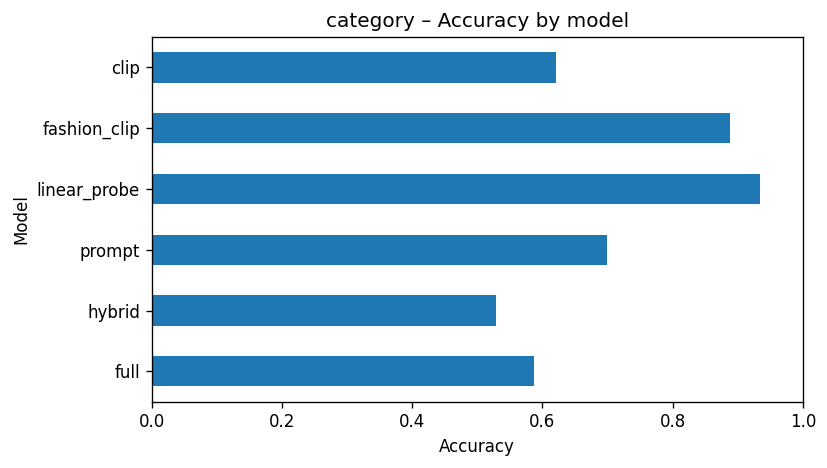

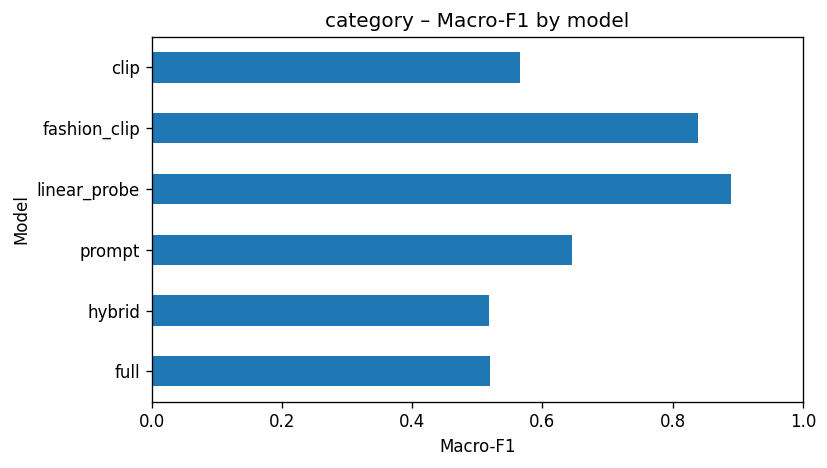


=== category – Δ vs clip (head) ===
              accuracy  precision_macro  recall_macro  f1_macro  \
model                                                             
full         -0.034454        -0.120639      0.031261 -0.045561   
hybrid       -0.092248        -0.044939     -0.040447 -0.046784   
prompt        0.078355         0.032986      0.061932  0.080996   
linear_probe  0.312587         0.258559      0.222992  0.324228   
fashion_clip  0.267852         0.199299      0.189650  0.274623   

              precision_weighted  recall_weighted  f1_weighted  
model                                                           
full                    0.000988        -0.034454    -0.000965  
hybrid                 -0.052030        -0.092248    -0.087573  
prompt                  0.056359         0.078355     0.100764  
linear_probe            0.194651         0.312587     0.318101  
fashion_clip            0.156699         0.267852     0.273109  


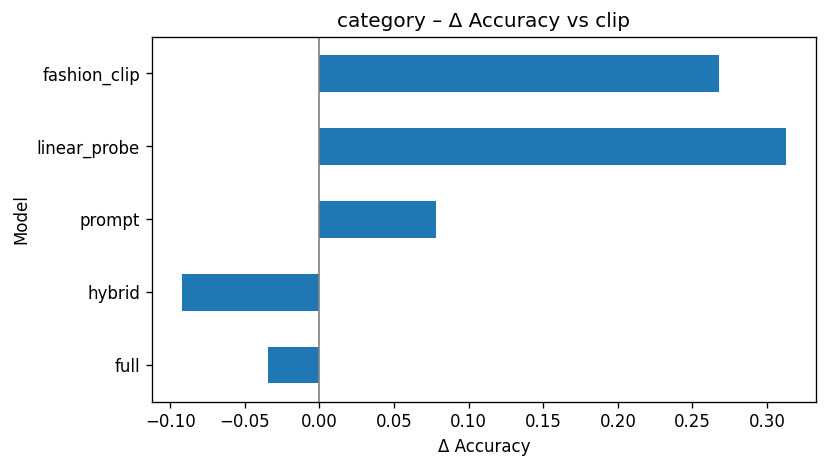

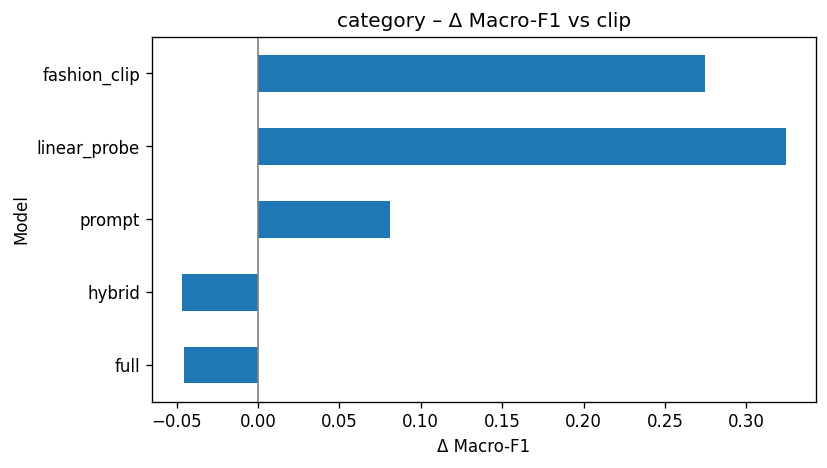


=== category – Δ vs fashion_clip (head) ===
              accuracy  precision_macro  recall_macro  f1_macro  \
model                                                             
full         -0.302306        -0.319938     -0.158389 -0.320184   
hybrid       -0.360100        -0.244238     -0.230096 -0.321408   
prompt       -0.189497        -0.166312     -0.127718 -0.193627   
linear_probe  0.044735         0.059261      0.033342  0.049605   
fashion_clip  0.000000         0.000000      0.000000  0.000000   

              precision_weighted  recall_weighted  f1_weighted  
model                                                           
full                   -0.155712        -0.302306    -0.274073  
hybrid                 -0.208730        -0.360100    -0.360682  
prompt                 -0.100341        -0.189497    -0.172344  
linear_probe            0.037952         0.044735     0.044992  
fashion_clip            0.000000         0.000000     0.000000  


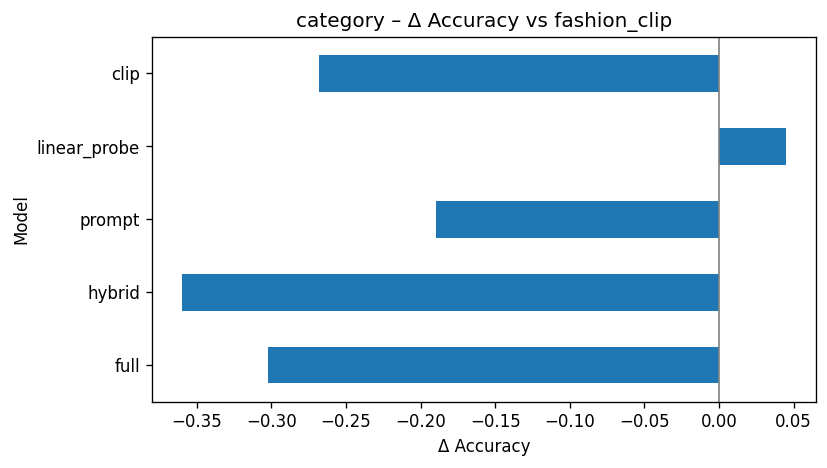

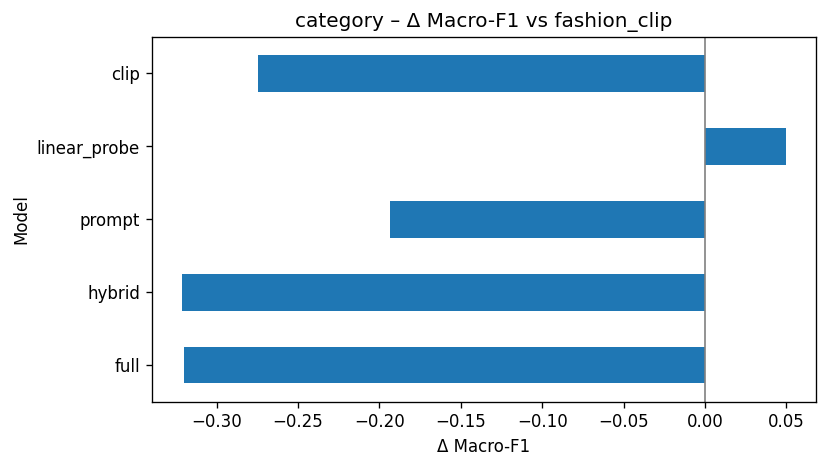


=== sub_category – single-label metrics (head) ===
              accuracy  precision_macro  recall_macro  f1_macro  \
model                                                             
clip          0.268964         0.250534      0.291408  0.188437   
fashion_clip  0.531537         0.359201      0.416823  0.328478   
full          0.302028         0.261843      0.325691  0.190589   
hybrid        0.320922         0.255397      0.306753  0.209693   
linear_probe  0.696305         0.309180      0.283728  0.286412   

              precision_weighted  recall_weighted  f1_weighted  
model                                                           
clip                    0.569448         0.268964     0.305009  
fashion_clip            0.720169         0.531537     0.581833  
full                    0.746450         0.302028     0.331164  
hybrid                  0.581032         0.320922     0.372784  
linear_probe            0.652107         0.696305     0.657997  


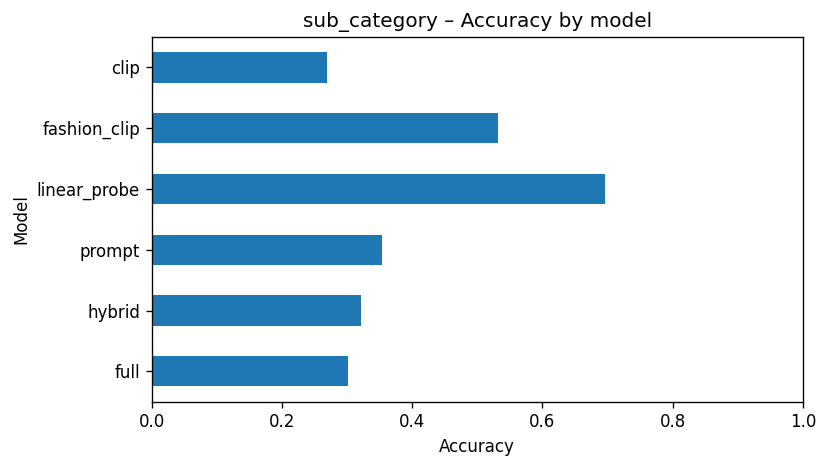

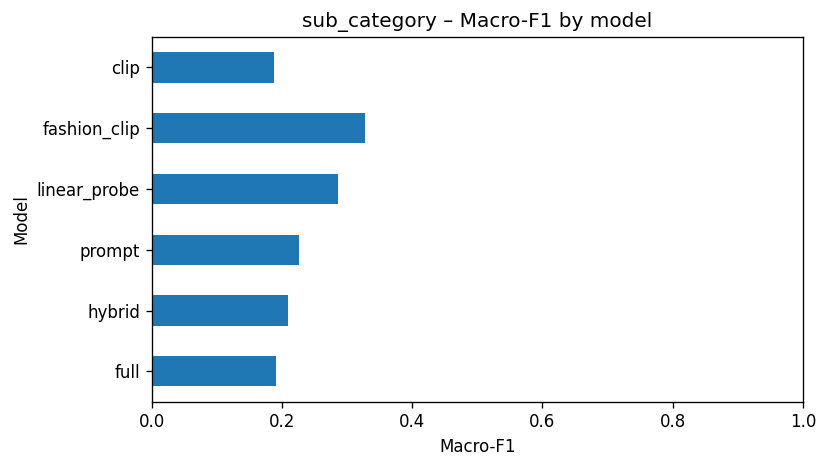


=== sub_category – Δ vs clip (head) ===
              accuracy  precision_macro  recall_macro  f1_macro  \
model                                                             
full          0.033065         0.011309      0.034283  0.002152   
hybrid        0.051959         0.004863      0.015345  0.021256   
prompt        0.085579         0.013730      0.033354  0.038233   
linear_probe  0.427341         0.058646     -0.007680  0.097974   
fashion_clip  0.262573         0.108667      0.125415  0.140041   

              precision_weighted  recall_weighted  f1_weighted  
model                                                           
full                    0.177002         0.033065     0.026154  
hybrid                  0.011584         0.051959     0.067774  
prompt                  0.027690         0.085579     0.102446  
linear_probe            0.082660         0.427341     0.352987  
fashion_clip            0.150722         0.262573     0.276824  


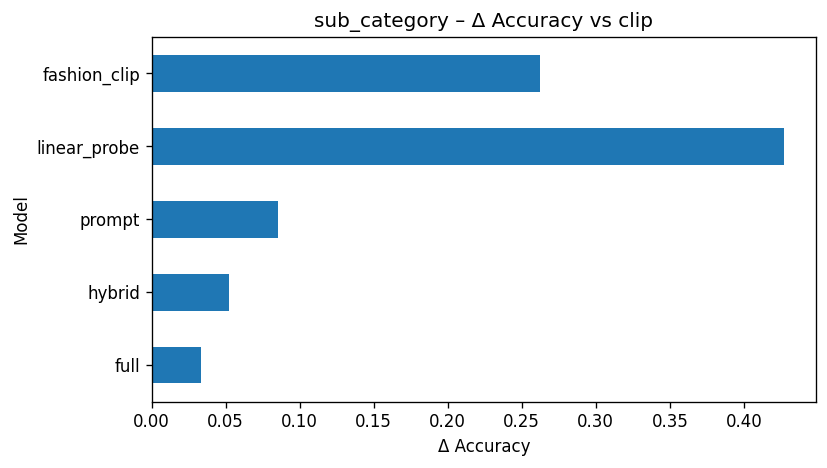

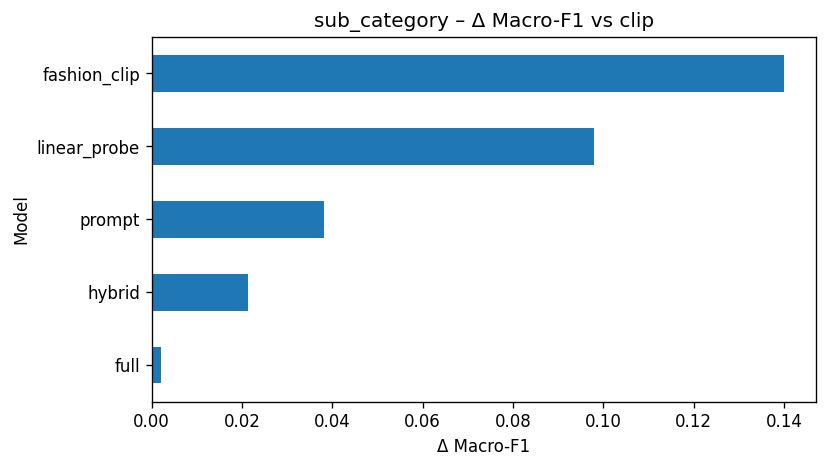


=== sub_category – Δ vs fashion_clip (head) ===
              accuracy  precision_macro  recall_macro  f1_macro  \
model                                                             
full         -0.229508        -0.097358     -0.091132 -0.137889   
hybrid       -0.210614        -0.103804     -0.110069 -0.118785   
prompt       -0.176994        -0.094937     -0.092060 -0.101808   
linear_probe  0.164768        -0.050021     -0.133095 -0.042067   
fashion_clip  0.000000         0.000000      0.000000  0.000000   

              precision_weighted  recall_weighted  f1_weighted  
model                                                           
full                    0.026281        -0.229508    -0.250669  
hybrid                 -0.139138        -0.210614    -0.209050  
prompt                 -0.123032        -0.176994    -0.174378  
linear_probe           -0.068062         0.164768     0.076163  
fashion_clip            0.000000         0.000000     0.000000  


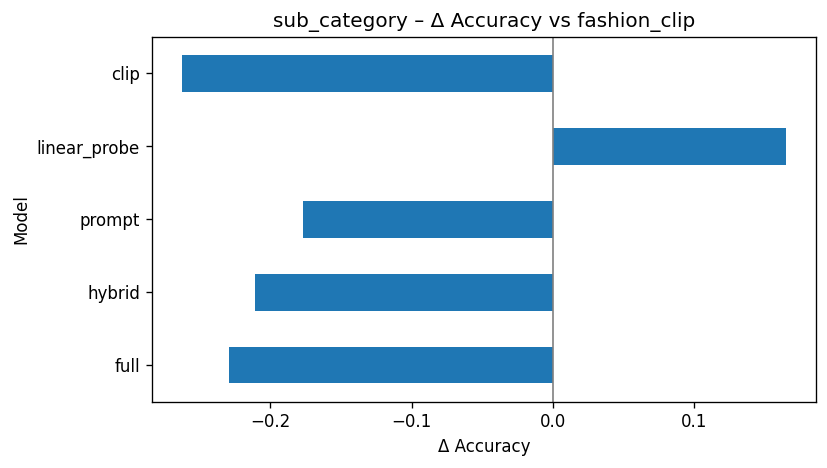

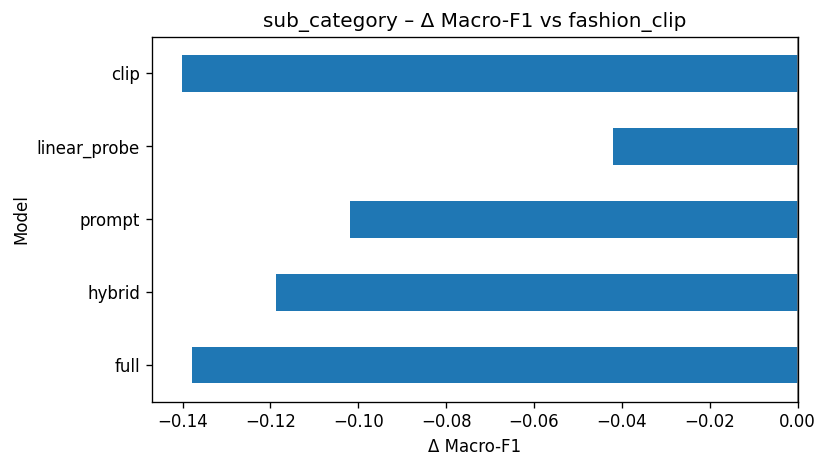

In [9]:
# Single-label evaluation computed directly from your field tables (no re-building).
# Metrics: Accuracy, macro-Precision/Recall/F1, weighted-Precision/Recall/F1.
# Additionally, produce two delta tables per field: vs 'clip' and vs 'fashion_clip'.

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

SINGLE_FIELDS = ["category", "sub_category"]
single_results = {}              # field -> metrics df
single_baseline_deltas = {}      # field -> {baseline_name: delta_df}

# ✅ 固定的顯示順序（供所有圖表與 delta 使用）
desired_order = ["full", "hybrid", "prompt", "linear_probe", "fashion_clip", "clip"] 

for field in SINGLE_FIELDS:
    tbl = tables[field].copy()
    models = get_models_from_table(tbl)

    # Align ground truth to the table's image order
    gt_aligned = gt.set_index("image_id").reindex(tbl["image_id"])[field].apply(norm_single)

    rows = []
    for m in models:
        y_pred = tbl[m].apply(norm_single)

        acc = accuracy_score(gt_aligned, y_pred)
        # macro average (each class equal weight)
        p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
            gt_aligned, y_pred, average="macro", zero_division=0
        )
        # weighted average (weighted by support)
        p_weight, r_weight, f_weight, _ = precision_recall_fscore_support(
            gt_aligned, y_pred, average="weighted", zero_division=0
        )

        rows.append({
            "model": m,
            "accuracy": acc,
            "precision_macro": p_macro, "recall_macro": r_macro, "f1_macro": f_macro,
            "precision_weighted": p_weight, "recall_weighted": r_weight, "f1_weighted": f_weight
        })

    metrics_df = pd.DataFrame(rows).set_index("model")
    single_results[field] = metrics_df

    # Save the metrics table
    metrics_csv = os.path.join(SAVE_DIR, f"singlelabel_metrics_{field}.csv")
    metrics_df.to_csv(metrics_csv)

    # Print quick preview
    print(f"\n=== {field} – single-label metrics (head) ===")
    print(metrics_df.head(5))

    # ✅ 固定顯示順序（即使有些 model 不存在也不影響，繪圖會自動跳過 NaN）
    metrics_df = metrics_df.reindex(desired_order)

    # Plot bars for Accuracy and Macro-F1（✅ 改為橫向長條圖）
    for metric, title in [("accuracy", "Accuracy"), ("f1_macro", "Macro-F1")]:
        fig, ax = plt.subplots(figsize=(7,4))
        metrics_df[metric].plot(kind="barh", ax=ax)
        ax.set_xlim(0, 1)
        ax.set_title(f"{field} – {title} by model")
        ax.set_xlabel(title)
        ax.set_ylabel("Model")
        save_fig(fig, os.path.join(SAVE_DIR, f"singlelabel_{metric}_{field}.png"))

    # Baseline delta tables: vs 'clip' and vs 'fashion_clip'
    baseline_maps = {}
    for baseline in ["clip", "fashion_clip"]:
        if baseline not in metrics_df.index:
            print(f"[Info] Baseline '{baseline}' not found in {field} table; skip delta.")
            continue

        # 以 baseline 行做差
        delta_df = metrics_df.subtract(metrics_df.loc[baseline], axis=1)
        baseline_maps[baseline] = delta_df

        # 先輸出完整 CSV（✅ 保留 baseline 自己在表中）
        delta_csv = os.path.join(SAVE_DIR, f"singlelabel_delta_vs_{baseline}_{field}.csv")
        delta_df.to_csv(delta_csv)
        print(f"\n=== {field} – Δ vs {baseline} (head) ===")
        print(delta_df.head(5))

        # ✅ 固定順序（與上方一致）
        delta_df = delta_df.reindex(desired_order)

        # ✅ 繪圖時排除 baseline 自己
        plot_order = [m for m in desired_order if m != baseline and m in delta_df.index]
        delta_plot_df = delta_df.loc[plot_order]

        # Optional: plot delta for Accuracy and Macro-F1（✅ 橫向，並加 0 基準線）
        for metric, title in [("accuracy", "Δ Accuracy"), ("f1_macro", "Δ Macro-F1")]:
            fig, ax = plt.subplots(figsize=(7,4))
            delta_plot_df[metric].plot(kind="barh", ax=ax)
            ax.axvline(0.0, color="gray", linewidth=1)
            ax.set_title(f"{field} – {title} vs {baseline}")
            ax.set_xlabel(title)
            ax.set_ylabel("Model")
            save_fig(fig, os.path.join(SAVE_DIR, f"singlelabel_{metric}_delta_vs_{baseline}_{field}.png"))

    single_baseline_deltas[field] = baseline_maps
